<a href="https://colab.research.google.com/github/heidygv-ux/Prediction-models/blob/main/TP1/01_RF_prediction_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Random Forest (RF) machine learning algorithms are very effective for predicting weather events**

> Satellite data




In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from google.colab import files
import warnings
warnings.filterwarnings('ignore')


In [ ]:

df = pd.read_excel('datomerra.xlsx')

df['Fecha'] = pd.to_datetime(df['Fecha'])
df.set_index('Fecha', inplace=True)
df = df.sort_index()

print(f" Period: {df.index.min().strftime('%Y-%m')} a {df.index.max().strftime('%Y-%m')}")
print(f" Total months: {len(df)}")
print(f" Variables: {list(df.columns)}")

print("\n Descriptive statistics:")
print(df.describe().round(2))

 Period: 1996-01 a 2025-12
 Total months: 360
 Variables: ['Merrapreci', 'ETP', 'Hsuelo']

 Descriptive statistics:
       Merrapreci     ETP  Hsuelo
count      360.00  360.00  360.00
mean        55.10  159.15    0.62
std         96.68   22.33    0.10
min          0.03  104.06    0.55
25%          1.32  141.36    0.56
50%          7.98  161.94    0.56
75%         65.02  175.56    0.63
max        596.47  209.81    1.00


The variables entered into RF have cyclical months.

In [ ]:
df['Hsuelo_lag1'] = df['Hsuelo'].shift(1)
df['Pre_lag1']      = df['Merrapreci'].shift(1)
df['ETP_lag1']      = df['ETP'].shift(1)
df['mes_sen'] = np.sin(2 * np.pi * df.index.month / 12)
df['mes_cos'] = np.cos(2 * np.pi * df.index.month / 12)

df = df.dropna().reset_index(drop=False)

print(f"Dataset con features: {len(df)} meses")
print(f"\nInput variables:")
FEATURES = ['Merrapreci', 'ETP', 'Hsuelo_lag1', 'Pre_lag1', 'ETP_lag1', 'mes_sen', 'mes_cos']
TARGET   = 'Hsuelo'
for f in FEATURES:
    print(f"   → {f}")
print(f"\nOutput variable: {TARGET}")

Dataset con features: 359 meses

Input variables:
   → Merrapreci
   → ETP
   → Hsuelo_lag1
   → Pre_lag1
   → ETP_lag1
   → mes_sen
   → mes_cos

Output variable: Hsuelo


In [ ]:
#Data separation
TARGET   = 'Hsuelo'
FEATURES = ['Merrapreci', 'ETP', 'Hsuelo_lag1', 'Pre_lag1', 'ETP_lag1', 'mes_sen', 'mes_cos']
corte = df[df['Fecha'] == '2021-01-01'].index[0]

X_train = df[FEATURES].iloc[:corte]
X_test  = df[FEATURES].iloc[corte:]
y_train = df[TARGET].iloc[:corte]
y_test  = df[TARGET].iloc[corte:]
fechas_test = df['Fecha'].iloc[corte:]

print(f" Training: {df['Fecha'].iloc[0].strftime('%b %Y')} → "
      f"{df['Fecha'].iloc[corte-1].strftime('%b %Y')} ({len(X_train)} meses)")
print(f" Test:        {df['Fecha'].iloc[corte].strftime('%b %Y')} → "
      f"{df['Fecha'].iloc[-1].strftime('%b %Y')} ({len(X_test)} meses)")

 Training: Feb 1996 → Dec 2020 (299 meses)
 Test:        Jan 2021 → Dec 2025 (60 meses)


In [ ]:
rf_model = RandomForestRegressor(
    n_estimators     = 300,
    max_depth        = 10,
    min_samples_split = 5,
    min_samples_leaf  = 2,
    random_state     = 42,
    n_jobs           = -1
)

rf_model.fit(X_train, y_train)
print(" Successful training")
print(f" Trained trees: {rf_model.n_estimators}")
print(f"  Features used: {rf_model.n_features_in_}")

 Successful training
 Trained trees: 300
  Features used: 7


In [ ]:
y_pred_test  = rf_model.predict(X_test)
y_pred_train = rf_model.predict(X_train)
#Evaluation metrics
rmse_test = np.sqrt(mean_squared_error(y_test, y_pred_test))
mae_test  = mean_absolute_error(y_test, y_pred_test)
r2_test   = r2_score(y_test, y_pred_test)
# Training metric
rmse_train = np.sqrt(mean_squared_error(y_train, y_pred_train))
r2_train   = r2_score(y_train, y_pred_train)

print("=" * 52)
print("       EVALUATION METRICS — RF")
print("=" * 52)
print(f"  TRAINING       →  RMSE: {rmse_train:.4f}  |  R²: {r2_train:.4f}")
print(f"  TEST           →  RMSE: {rmse_test:.4f}  |  R²: {r2_test:.4f}")
print(f"  TEST           →  MAE:  {mae_test:.4f}")
print("=" * 52)

if r2_train - r2_test > 0.15:
    print(" Possible overadjustment")
else:
    print(" No sign of overadjustment")

import matplotlib.pyplot as plt
from scipy.stats import pearsonr

pearson_corr, _ = pearsonr(y_test, y_pred_test)

print(f" Pearson correlation test: {pearson_corr:.4f}")
print("=" * 52)


       EVALUATION METRICS — RF
  TRAINING       →  RMSE: 0.0111  |  R²: 0.9878
  TEST           →  RMSE: 0.0292  |  R²: 0.9275
  TEST           →  MAE:  0.0170
 No sign of overadjustment
 Pearson correlation test: 0.9644



IMPORTANCE OF VARIABLES:
---------------------------------------------
  Pre_lag1             ████████████████████████████████████████████ 0.8806
  Merrapreci           ███ 0.0722
  Hsuelo_lag1          █ 0.0324
  ETP                   0.0089
  ETP_lag1              0.0036
  mes_sen               0.0017
  mes_cos               0.0006


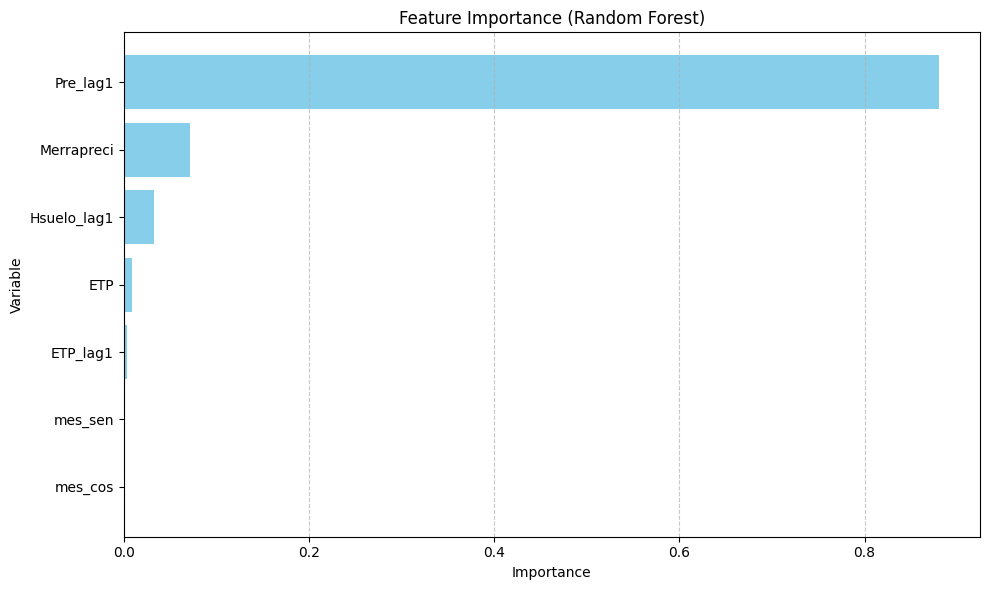

In [ ]:
importance = pd.DataFrame({
    'Variable':    FEATURES,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False).reset_index(drop=True)

print("\nIMPORTANCE OF VARIABLES:")
print("-" * 45)
for _, row in importance.iterrows():
    barra = '█' * int(row['Importance'] * 50)
    print(f"  {row['Variable']:<20} {barra} {row['Importance']:.4f}")

# Create a bar plot for feature importance
plt.figure(figsize=(10, 6))
plt.barh(importance['Variable'], importance['Importance'], color='skyblue')
plt.xlabel('Importance')
plt.ylabel('Variable')
plt.title('Feature Importance (Random Forest)')
plt.gca().invert_yaxis()
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

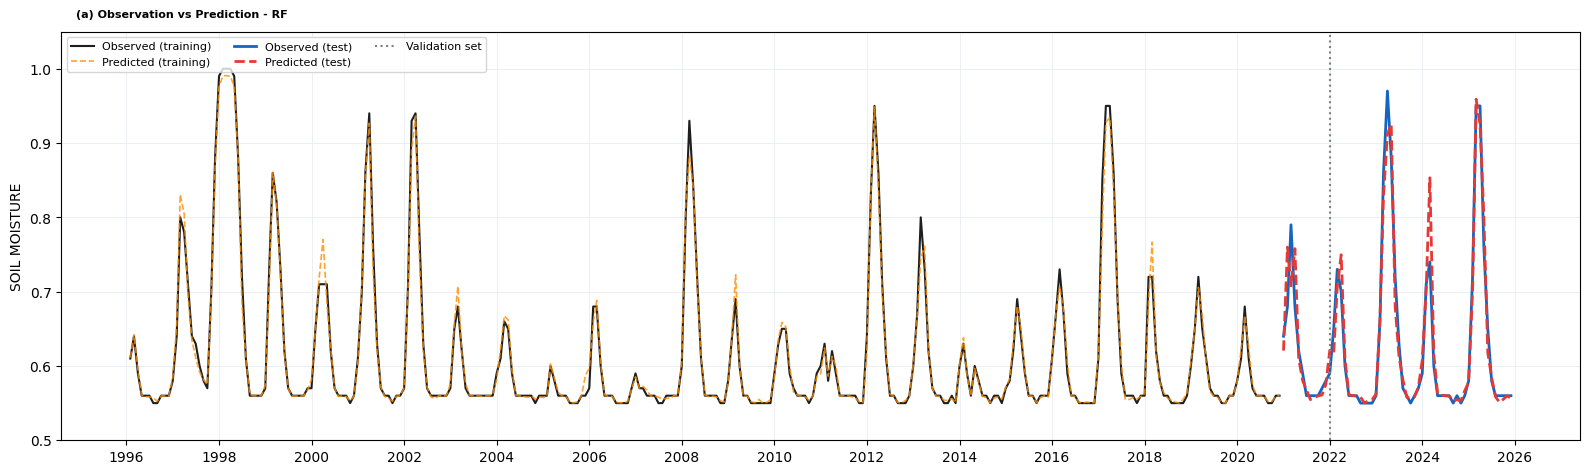

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
fig = plt.figure(figsize=(16, 18))

colores = {
    'real_train': '#1E1E1E',
    'real_test':  '#1565C0',
    'pred_train': '#FF8C00',
    'pred_test':  '#E53935',
    'barras':     '#43A047',
    'grid':       '#ECEFF1'
}

#Time series graph
ax1 = fig.add_subplot(4, 1, 1)
ax1.plot(df['Fecha'].iloc[:corte], y_train,
         color=colores['real_train'], linewidth=1.5, label='Observed (training)')
ax1.plot(df['Fecha'].iloc[:corte], y_pred_train,
         color=colores['pred_train'], linewidth=1.2, alpha=0.8, linestyle='--',
         label='Predicted (training)')
ax1.plot(fechas_test, y_test,
         color=colores['real_test'], linewidth=2, label='Observed (test)')
ax1.plot(fechas_test, y_pred_test,
         color=colores['pred_test'], linewidth=2, linestyle='--',
         label='Predicted (test)')
ax1.axvline(pd.Timestamp('2022-01-01'), color='gray', linestyle=':', linewidth=1.5,
            label='Validation set')

ax1.set_ylabel('SOIL MOISTURE', fontsize=10)
ax1.text(0.01, 1.03, '(a) Observation vs Prediction - RF', transform=ax1.transAxes, fontsize=8, verticalalignment='bottom', horizontalalignment='left', fontweight='bold')

ax1.legend(fontsize=8, ncol=3, loc='upper left')
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax1.xaxis.set_major_locator(mdates.YearLocator(2))
ax1.grid(True, color=colores['grid'], linewidth=0.7)
ax1.set_ylim(0.50, 1.05)

plt.tight_layout()
plt.savefig('scatter.png',
           dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

files.download('scatter.png')

In [ ]:
from sklearn.metrics import roc_auc_score, roc_curve
import matplotlib.pyplot as plt

UMBRAL = 0.5600

y_clase_rf   = (y_test < UMBRAL).astype(int)

auc_rf   = roc_auc_score(y_clase_rf,   -y_pred_test)

print("═" * 45)
print("   AREA BAJO LA CURVA (AUC-ROC)")
print("═" * 45)
print(f"  Random Forest : {auc_rf:.3f}")
print("═" * 45)

═════════════════════════════════════════════
   ÁREA BAJO LA CURVA (AUC-ROC)
═════════════════════════════════════════════
  Random Forest : 0.951
═════════════════════════════════════════════


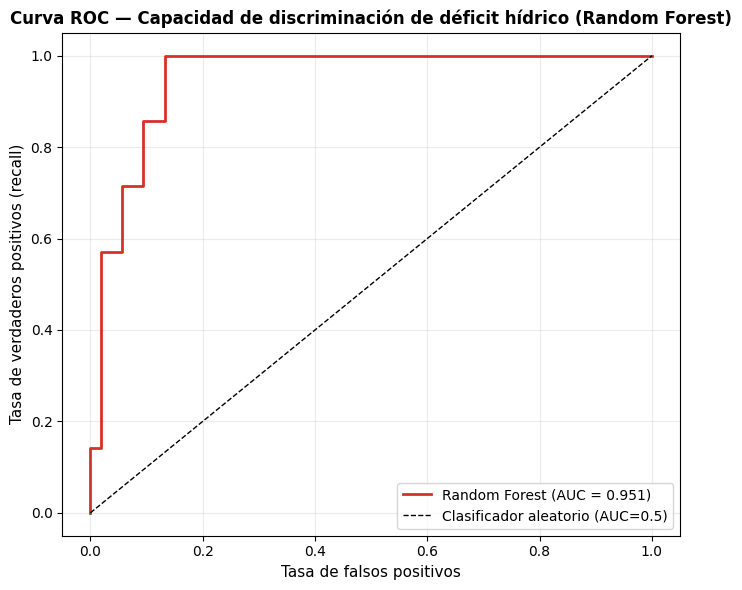

✓ Figura guardada: ROC_AUC_simple.png


In [ ]:
fig, ax = plt.subplots(figsize=(7, 6))

fpr_rf, tpr_rf, _ = roc_curve(y_clase_rf, -y_pred_test)

ax.plot(fpr_rf, tpr_rf, lw=2, color='#d73027', label=f'Random Forest (AUC = {auc_rf:.3f})')
ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Clasificador aleatorio (AUC=0.5)')

ax.set_xlabel('Tasa de falsos positivos', fontsize=11)
ax.set_ylabel('Tasa de verdaderos positivos (recall)', fontsize=11)
ax.set_title('Curva ROC — RF)',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=10, loc='lower right')
ax.grid(alpha=0.25)

plt.tight_layout()
plt.savefig('ROC_AUC_simple.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()
print("Figura guardad: ROC_RF.png")